# **1. ResNet-50 구현**

## **1-1. ResNet-50를 구현하게 된 동기**
딥러닝 서적과 프리코스 강좌, 부스트캠프 강좌 모두에서 언급하는 유명한 모델이어서 구현하지 않고 넘어갈 수 없었습니다.  
또한 보다 깊은 모델을 구현하는 연습을 할 수 있었기에 ResNet-50을 구현하기로 했습니다.

## **1-2. 구현에 참고한 논문**
**[1] Deep Residual Learning for Image Recognition**
([논문 링크](https://arxiv.org/abs/1512.03385))

위 논문을 참고해 ResNet-50을 구현했습니다. Shortcut Connection 도입하면서 저자들이 어떤 생각을 했는지 볼 수 있었고 덕분에 재밌게 읽었습니다. 또 상당히 친절한 논문이었습니다. 자신들의 연구 결과를 독자들에게 잘 전달하고 또 이를 설득시키기 위해 여러모로 공들인 느낌을 받았습니다. 저같은 사람도 논문을 무난히 읽을 수 있게 작성해주셔서 감사했습니다.

추가로 논문을 읽으면서 든 생각은 논리와 실험 중 어느 게 먼저였을까 하는 생각이었습니다. 저자들은 논리를 세우고 이를 입증하기 위한 실험을 수행했을까요, 아니면 실험을 수행하고 그 결과를 잘 설명할 수 있는 논리를 세운 것일까요? 그냥 읽고 나니 이런 궁금증이 좀 들었습니다. 이런 개인적인 생각도 의미가 있을까 싶어 기록해봅니다.


## **1-3. 구현 및 학습 실험 후기**
* ResNet-34와 달리 ResNet-50은 병목 구조를 가지고 있어서 구현이 까다로웠습니다. shortcut connection이 있어야 할 때와 그렇지 않을 때를 잘 구별해서 구현하는 게 핵심이었던 것 같습니다. 구현 과정에서 논문을 여러 번 되짚어보면서 ResNet을 더 잘 이해하게 된 것 같습니다.

* Pytorch에 구현된 ResNet-50 모델과 비교하면서 잘못 구현된 부분이 있나 점검했습니다. 생각보다 일치하지 않는 부분이 많았고 아직 저의 구현 역량이 부족하다는 걸 알 수 있었습니다. 일치하지 않는 부분은 수정해서 다시 제대로 구현했습니다.

* ResNet-50은 VGGNet-16보다 레이어를 3배 더 쌓은 모델임에도 모델 성능이 가파르게 올라가고 학습에 더 적은 시간이 소요되었습니다. 또한 파라미터가 VGGNet-16의 1/5도 되지 않음에도 (138M vs 26M) 그에 뒤지지 않는 성능을 보여주었습니다. Shortcut connection이 강력한 장치라는 걸 체감할 수 있었습니다.

* 논문에 나온 대로 ResNet-50이 VGGNet-16보다 더 좋은 성능을 보여주었습니다. 하지만 VGGNet-16에 배치놈을 추가한 VGG16-bn보다는 성능이 낮게 나오지 않았습니다. 수 차례 학습시켜봤지만 VGG16-bn의 이미지 분류 정확도가 더 높게 나왔습니다. 2주간 코드를 검토하고 실험을 반복했지만 결과는 마찬가지였고, 그렇게 문제의 원인을 알아내지 못한 채 마무리하나 싶었는데 우연히 ViT 논문을 읽던 중 이에 대한 실마리를 찾을 수 있었습니다. 이에 대해 몇 자 적어봅니다.
    - **오버피팅** : 깊고 복잡한 모델일수록 오버피팅에 취약해 얕은 모델보다 성능이 안좋게 나올 수 있다는 걸 ViT 논문을 읽으면서 새로 알게 되었습니다. 저의 학습 실험에서 VGG16-bn이 ResNet-50보다 나은 성능을 보인 것도 아마 이와 같은 이유가 아닐까 생각합니다. 학습에 사용한 데이터셋은 훈련 데이터가 1만개 정도로 작은 데이터셋이었고, 그래서 ResNet-50이 오버피팅에 취약해져 VGGNet-16보다 정확도가 낮게 나온 것으로 보입니다.

    - **모델 이상 무**: 오버피팅에 대해 알게 된 후 든 생각은 '그럼 Pytorch에 구현된 ResNet-50을 가져다 훈련시켜도 결과는 여전히 VGG16-bn보다 안좋게 나오겠네?'였습니다. Pytorch에 구현된 ResNet-50을 가져다 학습시켜봤지만 전과 동일하게 VGG16-bn보다 성능이 낮게 나왔습니다. 따라서 코드나 모델의 이상보다는 작은 데이터셋으로 인한 오버피팅으로 인해 ResNet-50의 성능이 VGGNet-16보다 낫게 나온 것으로 현 상황을 이해하고 있습니다.
    
    - **차후 실험 방향**: 데이터 증강에 대해 좀 더 공부한 뒤 다시 성능 비교 실험을 하려고 합니다. 또한 사전 훈련된 ResNet-50과 VGG16-bn을 파인튜닝했을 때 어느 쪽이 성능이 더 잘 나오는지 시험하려고 합니다. (구현6 참고)

## **1-4. 모델 구현**
Pytorch에 구현된 모델과 동일한 구조, 동일한 파라미터 수를 가지는 ResNet-50을 구현했습니다.

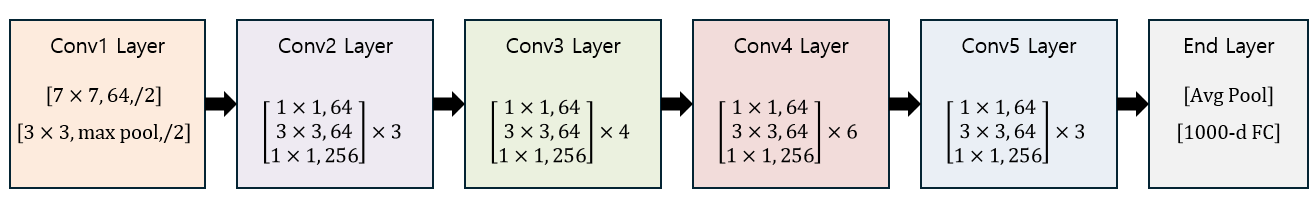

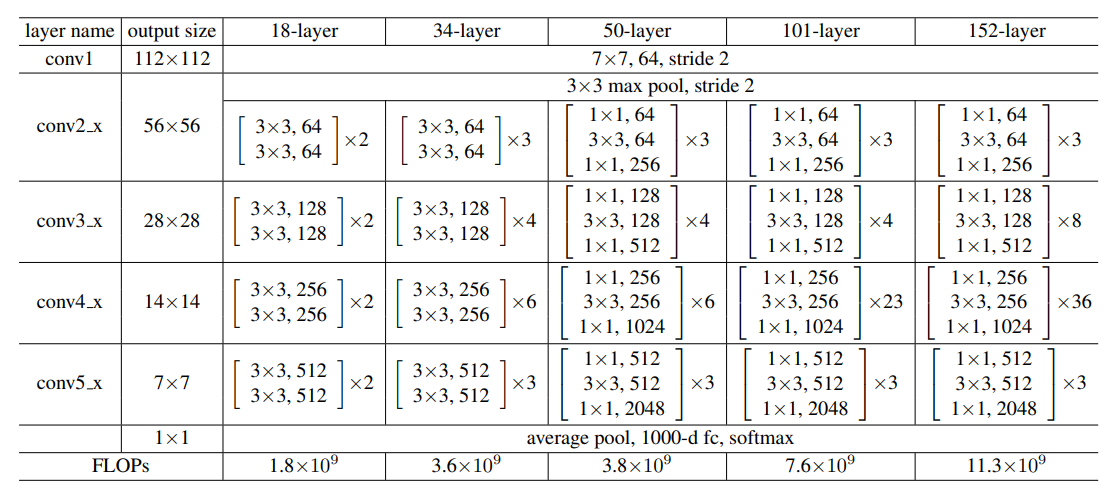

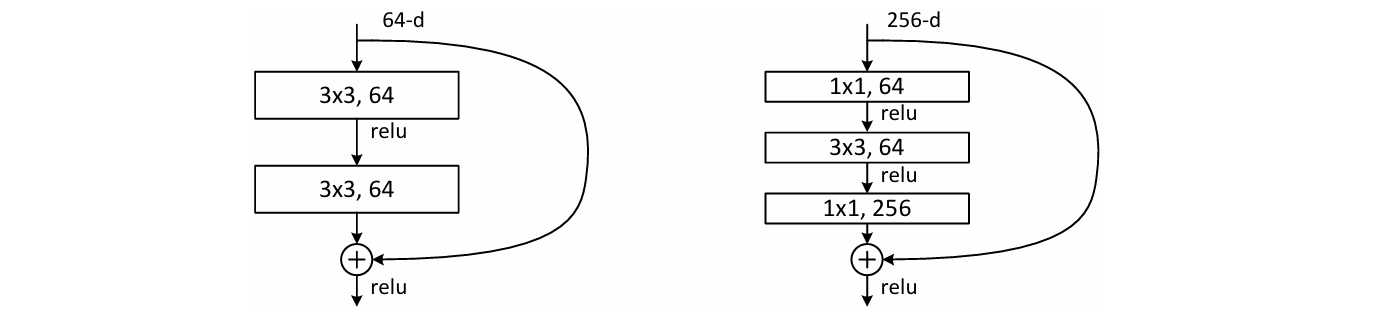

In [ ]:
import torch
import torch.nn as nn

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, norm='bn', relu=True):
        super().__init__()

        layers = []

        layers.append(nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False))

        if norm == 'bn':
            layers.append(nn.BatchNorm2d(out_channels))
        if relu is True:
            layers.append(nn.ReLU(inplace=True))

        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        x = self.layers(x)
        return x

In [ ]:
class ResBlock(nn.Module):
    def __init__(self, in_channels, inter_channels, out_channels, kernel_size=3, stride=1, padding=1, init_block=False):
        # init_block: True로 설정하면 Feature map 축소, False로 설정하면 Feature map 사이즈 유지

        # direct_short_cut: input의 채널 길이가 output의 채널 길이와 같을 땐 곧바로 더하기            (ResNet 논문에 나오는 식 (1) 참고)
        #                   input의 채널 길이가 output의 채널 길이와 다를 땐 1x1 Conv 적용하고 더하기 (ResNet 논문에 나오는 식 (2) 참고)

        super().__init__()
        if init_block:
            init_stride = 2
        else:
            init_stride = 1

        if in_channels == out_channels:
            direct_short_cut = True
        else:
            direct_short_cut = False

        self.conv1 = ConvBlock(in_channels,
                               inter_channels,
                               kernel_size = 1,
                               stride = stride,
                               padding = 0,
                               norm = 'bn',
                               relu = True)

        self.conv2 = ConvBlock(inter_channels,
                          inter_channels,
                          kernel_size = kernel_size,
                          stride = init_stride,
                          padding = 1,
                          norm = 'bn',
                          relu = True)

        self.conv3 = ConvBlock(inter_channels,
                          out_channels,
                          kernel_size = 1,
                          stride = stride,
                          padding = 0,
                          norm = 'bn',
                          relu = False)

        if direct_short_cut and init_stride == 1:
            self.residual = nn.Identity()
        else:
            self.residual = ConvBlock(in_channels,
                                out_channels,
                                kernel_size = 1,
                                stride = init_stride,
                                padding = 0,
                                norm = 'bn',
                                relu = False)

        self.relu = nn.ReLU(inplace=True)

        for layer in self.conv3.layers:
            if isinstance(layer, nn.BatchNorm2d):
                nn.init.constant_(layer.weight, 0.0)

    def forward(self, x):
        y = self.conv1(x)
        y = self.conv2(y)
        y = self.conv3(y)
        y = y + self.residual(x)
        y = self.relu(y)
        return y

In [ ]:
class ResNet50(nn.Module):
    def __init__(self, in_channels, out_channels, nker = 64):
        super().__init__()

        self.enc = ConvBlock(in_channels, nker, kernel_size = 7, stride = 2, padding = 3, norm = 'bn', relu = True) # 이 레이어를 통과하면 feature_map = (112x112)
        self.max_pool = nn.MaxPool2d(kernel_size = 3, stride = 2, padding=1)                                        # 이 레이어를 통과하면 feature_map = (56x56)

        self.conv = nn.Sequential(
            # conv2_x
            ResBlock(nker,   nker, 4*nker, init_block=False),       # 64  -> 64 -> 256   short_cut과 init_block이 같지 않은 유일한 구간. channel은 늘리지만 feature map은 축소하지 않음. 이 레이어를 통과하면 feature_map = (56x56)
            ResBlock(4*nker, nker, 4*nker, init_block=False),       # 256 -> 64 -> 256   이 레이어를 통과하면 feature_map = (56x56)
            ResBlock(4*nker, nker, 4*nker, init_block=False),       # 256 -> 64 -> 256   이 레이어를 통과하면 feature_map = (56x56)

            # conv3_x
            ResBlock(4*nker, 2*nker, 8*nker, init_block=True),      # 256 -> 128 -> 512  이 레이어를 통과하면 feature_map = (28x28)
            ResBlock(8*nker, 2*nker, 8*nker, init_block=False),     # 512 -> 128 -> 512  이 레이어를 통과하면 feature_map = (28x28)
            ResBlock(8*nker, 2*nker, 8*nker, init_block=False),     # 512 -> 128 -> 512  이 레이어를 통과하면 feature_map = (28x28)
            ResBlock(8*nker, 2*nker, 8*nker, init_block=False),     # 512 -> 128 -> 512  이 레이어를 통과하면 feature_map = (28x28)

            # conv4_x
            ResBlock(8*nker,  4*nker, 16*nker, init_block=True),    # 512  -> 256 -> 1024   이 레이어를 통과하면 feature_map = (14x14)
            ResBlock(16*nker, 4*nker, 16*nker, init_block=False),   # 1024 -> 256 -> 1024   이 레이어를 통과하면 feature_map = (14x14)
            ResBlock(16*nker, 4*nker, 16*nker, init_block=False),   # 1024 -> 256 -> 1024   이 레이어를 통과하면 feature_map = (14x14)
            ResBlock(16*nker, 4*nker, 16*nker, init_block=False),   # 1024 -> 256 -> 1024   이 레이어를 통과하면 feature_map = (14x14)
            ResBlock(16*nker, 4*nker, 16*nker, init_block=False),   # 1024 -> 256 -> 1024   이 레이어를 통과하면 feature_map = (14x14)
            ResBlock(16*nker, 4*nker, 16*nker, init_block=False),   # 1024 -> 256 -> 1024   이 레이어를 통과하면 feature_map = (14x14)

            # conv5_x
            ResBlock(16*nker, 8*nker, 32*nker, init_block=True),    # 1024 -> 512 -> 2048   이 레이어를 통과하면 feature_map = (7x7)
            ResBlock(32*nker, 8*nker, 32*nker, init_block=False),   # 2048 -> 512 -> 2048   이 레이어를 통과하면 feature_map = (7x7)
            ResBlock(32*nker, 8*nker, 32*nker, init_block=False),   # 2048 -> 512 -> 2048   이 레이어를 통과하면 feature_map = (7x7)
        )

        self.end_net = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(32*nker, out_channels),
        )

    def forward(self, x):
        x = self.enc(x)
        x = self.max_pool(x)
        x = self.conv(x)
        x = self.end_net(x)
        return x

In [ ]:
# 모델 출력 확인
input = torch.randn((2,3,224,224))
model = ResNet50(3, 1000)            # 분류 클래스를 1000가지로 설정하면 torch에 구현된 resnet50과 동일합니다. 파라미터도 25,557,032개로 일치합니다.
output = model(input)
print(f"output: {output.shape}")

total_param = 0
for param in model.parameters():
    total_param += param.numel()
print(f"num of param: {total_param}")

output: torch.Size([2, 1000])
num of param: 25557032


# **2. 데이터셋 다운로드, 데이터 증강, 데이터 시각화**
ImageNet은 너무 커서 Imagenette이라는 데이터셋을 사용했습니다.

분류할 클래스: 10가지

Train 데이터: 9469개

Val 데이터: 3925개

In [ ]:
import torchvision
from torchvision import datasets
from torchvision.transforms import v2
from torchvision.transforms import Lambda

random_seed = 42
torch.manual_seed(random_seed)
torch.cuda.manual_seed(random_seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
train_transform = v2.Compose([
    v2.Resize(256),
    v2.RandomCrop(size=224),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.RandomHorizontalFlip(p=0.5),
    # v2.RandomRotation(degrees=10),
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    v2.Normalize(mean=[0.485, 0.456, 0.406],
                 std=[0.229, 0.224, 0.225])
    ])

val_transform = v2.Compose([
    v2.Resize(256),
    v2.CenterCrop(size=224),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406],
                 std=[0.229, 0.224, 0.225])
    ])


train_data = datasets.Imagenette(root='./',
                                 split = 'train',
                                 size = 'full',
                                 download = True,
                                 transform = train_transform,
                                 )

val_data = datasets.Imagenette(root='./',
                               split = 'val',
                               size = 'full',
                               download = True,
                               transform = val_transform,
                               )

print(f"train 데이터: {len(train_data)}개")
print(f"val 데이터: {len(val_data)}개")

train 데이터: 9469개
val 데이터: 3925개


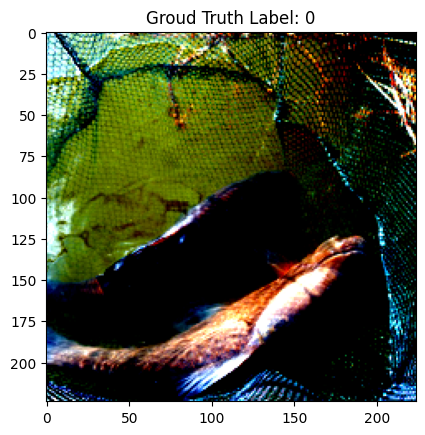

In [ ]:
import matplotlib.pyplot as plt

image, label = train_data[0]
plt.imshow(image.permute(1,2,0))
plt.title(f"Groud Truth Label: {label}")
plt.show()

# **3. ResNet-50 모델 학습 설정**

In [ ]:
# WandB 연결
import os, wandb
from google.colab import userdata

os.environ["WANDB_API_KEY"] = userdata.get('WANDB_API_KEY')
wandb.login()

wandb_run = wandb.init(project = 'Image Classification',
                       notes = 'ResNet-50 w/ Data Aug',
                       name = 'ResNet-50 w/ Data Aug',)

In [ ]:
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingWarmRestarts

device = 'cuda' if torch.cuda.is_available() else 'cpu'
learning_rate = 1e-4
batch_size = 64
epochs = 60

train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=6, drop_last=True)
val_dataloader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=6)
num_batch = len(train_dataloader)

model = ResNet50(3, 10)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0 = 5 * num_batch, eta_min = 1e-5)
# scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2, min_lr=1e-5)

In [ ]:
from tqdm import tqdm

def train(model, criterion, optimizer, train_dataloader, val_dataloader, epochs, device, batch_size, scheduler):
    model.to(device)
    model.train()

    best_acc = 0
    print_call = len(train_dataloader) // 5

    for epoch in range(1, epochs+1):
        print(f"======== Epoch: {epoch} ========")
        train_loss = 0
        correct = 0
        data_num = 0
        step = 0
        for inputs, targets in tqdm(train_dataloader, desc=f"Epoch {epoch}/{epochs}"):
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * targets.shape[0]

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == targets).sum().item()
            data_num += targets.shape[0]

            if step % print_call == 0:
                print(f"\tTrain Loss: {train_loss / data_num:.4f}, Train Acc: {correct/data_num*100:.2f}%")

            current_epoch = (epoch-1) + step / len(train_dataloader)

            log_dict = {
                "train/loss": loss.item(),
                "train/LR": scheduler.get_last_lr()[0],
                "epoch": current_epoch,
                }

            wandb.log(log_dict)

            step += 1
            scheduler.step()

        train_loss = train_loss / data_num
        train_acc = correct / data_num

        val_loss, val_acc = evaluation(model, criterion, val_dataloader, device, epoch)

        print(f"Epoch Summary({epoch}/{epochs}): Train Loss: {train_loss:.4f} // Val Loss: {val_loss:.4f} // Train Acc: {train_acc*100:.2f}% // Val Acc: {val_acc*100:.2f}%")

        if best_acc < val_acc:
                print(f"Best performance at epoch: {epoch}, {best_acc:.4f} -> {val_acc:.4f}\n")
                best_acc = val_acc
                torch.save(model.state_dict(), './best_model.pt')

def evaluation(model, criterion, val_dataloader, device, epoch):
    model.eval()
    correct = 0
    data_num = 0
    val_loss = 0

    with torch.no_grad():
        for inputs, targets in tqdm(val_dataloader, desc="Validation"):
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            val_loss += loss * targets.shape[0]
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == targets).sum().item()
            data_num += targets.shape[0]

        val_loss = val_loss / data_num
        val_acc = correct / data_num

    log_dict = {
        "val/loss": val_loss,
        "val/val acc": val_acc,
        "epoch": epoch,
        }

    wandb.log(log_dict)

    model.train()
    return val_loss, val_acc

# **4. 학습 시작!**

In [ ]:
train(model = model,
      criterion = criterion,
      optimizer = optimizer,
      train_dataloader = train_dataloader,
      val_dataloader = val_dataloader,
      epochs = epochs,
      device = device,
      batch_size = batch_size,
      scheduler = scheduler)

In [ ]:
wandb.finish()

# **5. 학습 결과 (25.09)**

여러 차례 실험 후 가장 높게 나온 성능을 기록했습니다.

| 실험 모델 | 데이터 증강 여부 | Validation Accuracy | 학습 상세 | 학습 시간 (L4 GPU) |
|-----------|------------------|:-------------------:|-----------|-----------|
| VGG16-bn |&nbsp;&nbsp;&nbsp;&nbsp; X                | 83.2%               |lr=1e-4, batch_size=64, epochs=20, 10 에폭에서 lr 1/10로 감소| 60분 (3분/epoch) |
| VGG16-bn |&nbsp;&nbsp;&nbsp;&nbsp; O (기본+좌우반전+색변화)               | 86.4%               |lr=1e-4, batch_size=64, epochs=14, 10 에폭에서 lr 1/10로 감소| 190분 (13.5분/epoch) |
| ResNet-50 |&nbsp;&nbsp;&nbsp;&nbsp; X                | 81.7%               |lr=2e-4, batch_size=32, epochs=10, ReduceLROnPlateau(factor=0.1, patience=2) 적용| 20분 (2분/epoch) |
| ResNet-50 |&nbsp;&nbsp;&nbsp;&nbsp; O (기본+좌우반전+색변화)               | 83.0%               |lr=1e-4, batch_size=32, epochs=15, 10 에폭에서 lr 1/10로 감소| 170분 (11.5분/epoch) |

# **6. 재학습 결과 (26.01)**

아래는 재학습한 결과입니다. 전과 마찬가지로 ResNet50의 성능이이 VGG-16-bn보다 잘 나오지 않았습니다.  
사전훈련된 ResNet50과 VGG-16-bn을 튜닝했을 때 결과가 어떻게 달라지는지 다음에 한번 비교해보려 합니다. (구현6 참고)

[적용한 데이터 증강]  
- RandomHorizontalFlip(p=0.5)  
- ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05)  

| No. | 실험 모델 | 데이터 증강 여부 | Validation Accuracy | 학습 상세 | 학습 시간 (L4 GPU) |
|-----|-----------|------------------|:-------------------:|-----------|-----------|
| 1 | VGG16    |&nbsp;&nbsp;&nbsp;&nbsp; X                | 78.98%               |lr=1e-4, batch_size=64, epochs=60, BatchNorm X| 92분 (1.5분/epoch) |
| 2 | VGG16    |&nbsp;&nbsp;&nbsp;&nbsp; O                | 82.37%               |lr=1e-4, batch_size=64, epochs=60, BatchNorm X| 92분 (1.5분/epoch)|
| 3 | **ResNet-50** |&nbsp;&nbsp;&nbsp;&nbsp; X                | **86.93%**               |lr=1e-4, batch_size=64, epochs=60 | 57분 (1분/epoch)|
| 4 | **ResNet-50** |&nbsp;&nbsp;&nbsp;&nbsp; O                | **87.34%**               |lr=1e-4, batch_size=64, epochs=60 | 57분 (1분/epoch)|
| 5 | VGG16-bn |&nbsp;&nbsp;&nbsp;&nbsp; X                | 89.71%               |lr=1e-4, batch_size=64, epochs=60, BatchNorm O | 112분 (1.9분/epoch)|
| 6 | VGG16-bn |&nbsp;&nbsp;&nbsp;&nbsp; O                | 90.75%               |lr=1e-4, batch_size=64, epochs=60, BatchNorm O | 112분 (1.9분/epoch)|

증강 여부를 기준으로 정렬하면 다음과 같습니다.

| No. | 실험 모델 | 데이터 증강 여부 | Validation Accuracy | 학습 상세 | 학습 시간 (L4 GPU) |
|-----|-----------|------------------|:-------------------:|-----------|-----------|
| 1 | VGG-16    |&nbsp;&nbsp;&nbsp;&nbsp; X                | 78.98%               |lr=1e-4, batch_size=64, epochs=60, BatchNorm X| 92분 (1.5분/epoch) |
| 2 | **ResNet-50** |&nbsp;&nbsp;&nbsp;&nbsp; X                | **86.93%**               |lr=1e-4, batch_size=64, epochs=60 | 57분 (1분/epoch)|
| 3 | VGG-16-bn |&nbsp;&nbsp;&nbsp;&nbsp; X                | 89.71%               |lr=1e-4, batch_size=64, epochs=60 | 112분 (1.9분/epoch)|
|-|-|&nbsp;&nbsp;&nbsp;&nbsp;-|-|-|-|
| 4 | VGG-16    |&nbsp;&nbsp;&nbsp;&nbsp; O                | 82.37%               |lr=1e-4, batch_size=64, epochs=60, BatchNorm X| 92분 (1.5분/epoch)|
| 5 | **ResNet-50** |&nbsp;&nbsp;&nbsp;&nbsp; O                | **87.34%**               |lr=1e-4, batch_size=64, epochs=60 | 57분 (1분/epoch)|
| 6 | VGG-16-bn |&nbsp;&nbsp;&nbsp;&nbsp; O                | 90.75%               |lr=1e-4, batch_size=64, epochs=60 | 112분 (1.9분/epoch)|

# **7. 로그, 모델 저장 및 불러오기**

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')
model_path  = "./best_model.pt"
save_path   = '/content/drive/MyDrive/Colab_Notebooks/Boost Camp AI Tech/구현/model/ResNet50_with_Augment.pt'

In [ ]:
# 모델 저장하기
import shutil

shutil.copy(model_path, save_path)

In [ ]:
# 모델 불러오기
pretrained_model = ResNet50(3,10)
pretrained_model.load_state_dict(torch.load(save_path, map_location='cuda')) # GPU를 사용하고 있다면 'cuda'로 설정하시길!
pretrained_model.eval()